In [ ]:
import pandas as pd
import json

In [ ]:
datasets_paths = {
  "job_skills_data": "jobs.lang-uk-job-skills.json"
}

In [ ]:
def clean_skill_data(item):
    """Extracts and cleans skills from the JSON structure.
    Assumes item['skills'] is either a list of strings or a dictionary
    with 'full_matches' and 'ngram_matches' keys."""
    raw_skills = []
    if isinstance(item.get('skills'), list): # Handle direct list of skills
        raw_skills = item['skills']
    elif isinstance(item.get('skills'), dict): # Handle nested dictionary structure
        all_matches = item['skills'].get('full_matches', []) + item['skills'].get('ngram_matches', [])
        raw_skills = [m['doc_node_value'] for m in all_matches]
    else:
        return [] # Return empty list if skills format is unexpected

    skills = [str(s).lower() for s in raw_skills]

    noise = ['com', 'job description', 'product name', 'brand names']
    clean = [s for s in skills if len(s) > 2 and s not in noise]
    return list(set(clean))

In [ ]:
def process_dataset_file(dataset_source, dataset_path):
    processed_records = []
    with open(dataset_path, 'r', encoding='utf-8') as f:
        # Read the entire file content and load as a single JSON object (assuming it's a list of job entries)
        data = json.load(f)

    # Assuming 'data' is a list of job entries
    for item in data:
        # Use 'title' from the item directly as per the new file description
        title = item.get('title', 'Unknown Title')

        skills = clean_skill_data(item)
        if skills:
            processed_records.append({
                'title': title,
                'skills': skills,
            })
    return pd.DataFrame(processed_records)

In [ ]:
datasets_dfs = []
for dataset_source, dataset_file in datasets_paths.items():
    datasets_dfs.append(process_dataset_file(dataset_source, dataset_file))

df = pd.concat(datasets_dfs, ignore_index=True)

In [ ]:
import numpy as np

# Define a mapping for similar job titles to a canonical form
title_mapping = {
    'data scientist': 'Data Scientist',
    'data science engineer': 'Data Scientist', # Grouping for consistency
    'data science': 'Data Scientist',
    'devops': 'DevOps Engineer',
    'azure devops': 'Azure DevOps Engineer',
    'automation qa': 'Automation Engineer',
    'automation engineer': 'Automation Engineer',
    'software development engineer in test': 'Automation Engineer', # SDET
    'sdet': 'Automation Engineer',
    'quality assurance engineer': 'QA Engineer',
    'test engineer': 'QA Engineer',
    'full stack developer': 'Full Stack Engineer',
    'backend developer': 'Backend Engineer',
    'frontend developer': 'Frontend Engineer',
    'mobile developer': 'Mobile Engineer',
    'cloud devops engineer': 'Cloud DevOps Engineer',
    'aws devops engineer': 'AWS DevOps Engineer',
    'site reliability engineer': 'DevOps Engineer',
    'sre': 'DevOps Engineer',
    'big data engineer': 'Big Data Engineer',
    'big data developer': 'Big Data Engineer',
    'machine learning engineer': 'Machine Learning Engineer',
    'ml engineer': 'Machine Learning Engineer',
    'ai engineer': 'AI Engineer',
    'computer vision engineer': 'Computer Vision Engineer',
    'nlp engineer': 'NLP Engineer',
    'deep learning engineer': 'Deep Learning Engineer',
    'software engineer': 'Software Engineer',
    'senior software engineer': 'Senior Software Engineer',
    'junior software engineer': 'Junior Software Engineer',
    'lead software engineer': 'Lead Software Engineer',
    'principal software engineer': 'Principal Software Engineer',
    'technical lead': 'Technical Lead',
    'architect': 'Architect',
    'solution architect': 'Solution Architect',
    'enterprise architect': 'Enterprise Architect',
    'cloud architect': 'Cloud Architect',
    'data architect': 'Data Architect',
    'cyber security engineer': 'Cyber Security Engineer',
    'security engineer': 'Cyber Security Engineer',
    'information security engineer': 'Cyber Security Engineer',
    'security analyst': 'Security Analyst',
    'information security analyst': 'Security Analyst',
    'soc analyst': 'SOC Analyst',
    'penetration tester': 'Penetration Tester',
    'ethical hacker': 'Penetration Tester',
    'qa automation engineer': 'Automation Engineer',
    'test automation specialist': 'Automation Engineer',
    'database developer': 'Database Developer',
    'sql developer': 'SQL Developer',
    'etl developer': 'ETL Developer',
    'data warehouse developer': 'Data Warehouse Developer',
    'web developer': 'Web Developer',
    'ios developer': 'Mobile Developer',
    'android developer': 'Mobile Developer',
    'javascript developer': 'JavaScript Developer',
    'python developer': 'Python Developer',
    'java developer': 'Java Developer',
    'c# developer': 'C# Developer',
    'php developer': 'PHP Developer',
    'go developer': 'Go Developer',
    'ruby developer': 'Ruby Developer',
    'scala developer': 'Scala Developer',
    'kotlin developer': 'Kotlin Developer',
    'swift developer': 'Swift Developer',
    'data analyst': 'Data Analyst',
    'business intelligence analyst': 'Data Analyst',
    'bi analyst': 'Data Analyst',
    'data visualization engineer': 'Data Visualization Engineer',
    'product owner': 'Product Manager',
    'scrum master': 'Scrum Master'
}

# Function to apply mapping
def normalize_job_title(title):
    # Convert to lowercase and strip whitespace for consistent mapping
    normalized_title = str(title).strip().lower()
    # Return the mapped title, or the original if no mapping exists
    return title_mapping.get(normalized_title, title)

# Create a copy of the original DataFrame to compare unique titles
df_original = df.copy()

# Apply the normalization to the 'title' column
df['title'] = df['title'].apply(normalize_job_title)

print(f"Original unique titles: {df_original['title'].nunique()}")
print(f"Unique titles after normalization: {df['title'].nunique()}")

Original unique titles: 6912
Unique titles after normalization: 6875


In [ ]:
df.head(n=100)

,title,skills
0,10 + Blockchain Nodes / Masternodes to set up,"[validators, collaboration, nodes, long term]"
1,10 .NET Developers (Middle and Senior level),"[microservices, core api, net http, react, bil..."
2,"10X Engineer (co-founder, #4 employee, USD 11-...","[python, website visitors, plan build, heroku,..."
3,1806/01 PHP Developer,"[problem solve, wireframes, translate, mysql, ..."
4,1812/35 Middle DataBase developer,"[milestones, data quality, business logic, sch..."
...,...,...
95,2D artist,"[sketching, game art, drawing, schedule, illus..."
96,2D Artist,"[2d graphics, figma, development process, engl..."
97,2D Artist,"[build event, team build, schedule, performanc..."
98,2D Artist,"[video editing, logos, social, animated, creat..."


In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# 1. Prepare strings: If your skills column contains lists, join them into text blocks
if isinstance(df['skills'].iloc[0], list):
    skills_processed = df['skills'].apply(lambda x: " ".join([str(s).strip().lower() for s in x]))
else:
    skills_processed = df['skills'].str.lower()

# Filter out infrequent classes before LabelEncoder and stratification
# Count occurrences of each title
title_counts = df['title'].value_counts()

# Identify titles that appear at least 2 times (required for stratification)
min_samples_per_class = 2
common_titles = title_counts[title_counts >= min_samples_per_class].index

# Filter the DataFrame to include only rows with common titles
df_filtered = df[df['title'].isin(common_titles)].copy()
skills_processed_filtered = skills_processed[df['title'].isin(common_titles)]

# 2. Extract numerical features via TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000, sublinear_tf=True, stop_words='english')
X = vectorizer.fit_transform(skills_processed_filtered).toarray()

# 3. Numeric conversions for the target titles (using filtered DataFrame)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_filtered['title'])
num_classes = len(label_encoder.classes_)

# 4. Partition data with stratification (Train, Validation, Test splits)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15/0.85), random_state=42, stratify=y_train_val
)

# 5. Handle class imbalance
trained_unique_classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=trained_unique_classes,
    y=y_train
)
class_weight_dict = {cls: w for cls, w in zip(trained_unique_classes, weights)}

print(f"📊 Training Matrix Shape: {X_train.shape}")
print(f"📊 Validation Matrix Shape: {X_val.shape}")
print(f"📊 Test Matrix Shape: {X_test.shape}")
print(f"🎯 Total Managed Job Classes: {num_classes}")

📊 Training Matrix Shape: (5118, 3000)
📊 Validation Matrix Shape: (1097, 3000)
📊 Test Matrix Shape: (1097, 3000)
🎯 Total Managed Job Classes: 887


In [ ]:
# =====================================================================
# STEP 2: NEURAL NETWORK DESIGN & OPTIMIZATION LOOP
# =====================================================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Construct the Multi-Layer Perceptron (MLP)
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    # Layer 1: Captures initial skill associations
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5), # Regularization to force actual pattern learning

    # Layer 2: Higher level abstract combination of features
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Final Softmax probability layer
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Add callbacks for improved training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=5, # Number of epochs with no improvement after which learning rate will be reduced.
    min_lr=0.00001, # Lower bound on the learning rate.
    verbose=1
)

print("🚀 Launching backpropagation weights training with Early Stopping and Learning Rate Reduction...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, # Increase epochs, EarlyStopping will manage when to stop
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate the model on the test set
print("\nEvaluating model on the test set...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Loss: {loss:.4f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")

🚀 Launching backpropagation weights training with Early Stopping and Learning Rate Reduction...
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.0098 - loss: 6.9225 - val_accuracy: 0.0146 - val_loss: 6.7362 - learning_rate: 0.0010
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.1499 - loss: 5.2816 - val_accuracy: 0.0319 - val_loss: 6.5721 - learning_rate: 0.0010
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3171 - loss: 3.7422 - val_accuracy: 0.0346 - val_loss: 5.9183 - learning_rate: 0.0010
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4588 - loss: 2.3703 - val_accuracy: 0.1522 - val_loss: 5.1399 - learning_rate: 0.0010
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5547 - loss: 1.3499 - val_accuracy: 0.1650 - val_loss: 4.7427 - learning_rate: 0.0010
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.6104 - loss: 0.7930 - val_accuracy: 0.2297 - val_loss: 4.4184 - learning_rate:

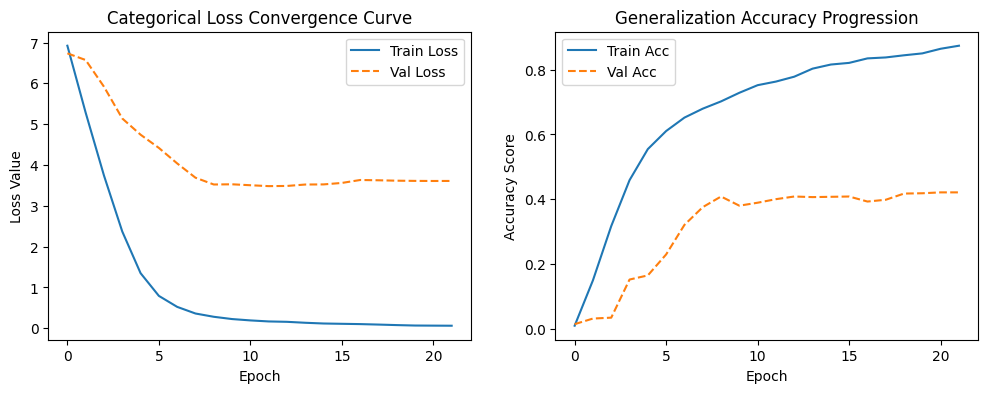

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

══════════════════════════════════════════════════
 🎯 SYSTEM INFERENCE: TOP MATCHING PROFESSIONAL ROLES
══════════════════════════════════════════════════
 Rank 1: Data Scientist                 | Confidence:  60.55%
 Rank 2: Computer Vision Engineer       | Confidence:  11.01%
 Rank 3: Deep Learning Engineer         | Confidence:   2.61%
══════════════════════════════════════════════════



In [ ]:
# =====================================================================
# ACADEMIC STEP 4: MODEL EVALUATION & INFERENCE INVERSION (CV -> ROLE)
# =====================================================================
import matplotlib.pyplot as plt

# 1. Plot the Learning Convergence Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Categorical Loss Convergence Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc', linestyle='--')
plt.title('Generalization Accuracy Progression')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

# 2. Define the Inference Engine for New CVs
def predict_roles_from_cv_skills(raw_cv_text, tfidf_vectorizer, trained_model, encoder, top_k=3):
    """
    Simulates production inference: Normalizes a raw unseen text block,
    vectorizes it, and extracts the Top K predicted matching job roles.
    """
    cleaned_input = str(raw_cv_text).strip().lower()
    vectorized_input = tfidf_vectorizer.transform([cleaned_input]).toarray()

    probabilities = trained_model.predict(vectorized_input)[0]
    top_k_indices = np.argsort(probabilities)[-top_k:][::-1]

    print("\n" + "═"*50)
    print(" 🎯 SYSTEM INFERENCE: TOP MATCHING PROFESSIONAL ROLES")
    print("═"*50)
    for rank, idx in enumerate(top_k_indices, 1):
        role_name = encoder.classes_[idx]
        match_confidence = probabilities[idx] * 100
        print(f" Rank {rank}: {role_name:<30} | Confidence: {match_confidence:>6.2f}%")
    print("═"*50 + "\n")

# --- LIVE PREDICTION TEST ---
# You can swap out this sample text with real skill phrases or summaries from your testing profiles!
unseen_test_cv = "proficient in python development, machine learning algorithms, pandas, scikit-learn, and neural networks architecture design"
predict_roles_from_cv_skills(unseen_test_cv, vectorizer, model, label_encoder)

In [ ]:
unseen_test_cv = """
John DoeRishon LeZion, Israel | +972 50-000-0000john.doe@email.com | LinkedIn Profile | GitHub RepositoryPROFESSIONAL SUMMARYResults-driven DevOps Engineer with 4+ years of experience specializing in automation, CI/CD pipeline optimization, and cloud infrastructure management. Proven track record of reducing deployment times and improving system reliability using AWS, Docker, and Kubernetes. Strong collaboration skills with development and QA teams to deliver scalable, secure software solutions.TECHNICAL SKILLSCloud Platforms: Amazon Web Services (AWS), Microsoft Azure, Google Cloud Platform (GCP)Infrastructure as Code: Terraform, Ansible, CloudFormationCI/CD Tools: Jenkins, GitHub Actions, GitLab CIContainer Orchestration: Docker, Kubernetes (EKS/AKS), HelmMonitoring & Logging: Prometheus, Grafana, Datadog, ELK StackProgramming & Scripting: Python, Bash, Shell, GoVersion Control & Others: Git, Jira, ConfluencePROFESSIONAL EXPERIENCECloud & DevOps EngineerTechSolutions Ltd. | Tel Aviv, IsraelJanuary 2024 – PresentInfrastructure Automation: Designed and maintained highly scalable infrastructure on AWS using Terraform and Ansible, reducing provisioning time by 40%.CI/CD Pipeline Optimization: Built and maintained end-to-end CI/CD pipelines using Jenkins and GitHub Actions, facilitating seamless deployments for microservices.Containerization & Kubernetes: Migrated legacy applications to Docker containers and orchestrated them using Kubernetes (EKS), resulting in improved resource utilization and 99.9% uptime.Monitoring & Alerting: Implemented comprehensive monitoring solutions using Prometheus and Grafana, reducing Mean Time to Resolution (MTTR) by 30%.Junior DevOps EngineerInnovateApps Inc. | Herzliya, IsraelJune 2021 – December 2023Release Management: Automated the build and deployment processes, collaborating closely with development teams to resolve deployment-related issues quickly.Configuration Management: Assisted in the configuration and management of Linux and Windows servers using Ansible, ensuring consistent environment setups across development, staging, and production.Version Control: Managed source code repositories on GitHub, implementing branch protection rules and standardizing Git workflows.Scripting: Developed Bash and Python scripts to automate routine administrative tasks and system backups.EDUCATIONB.Sc. in Computer ScienceTel Aviv University | Tel Aviv, IsraelGraduated: May 2021CERTIFICATIONSAWS Certified DevOps Engineer – Professional – Amazon Web ServicesCertified Kubernetes Administrator (CKA) – The Linux Foundation
"""
predict_roles_from_cv_skills(unseen_test_cv, vectorizer, model, label_encoder, top_k=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

══════════════════════════════════════════════════
 🎯 SYSTEM INFERENCE: TOP MATCHING PROFESSIONAL ROLES
══════════════════════════════════════════════════
 Rank 1: DevOps Engineer                | Confidence:  77.72%
 Rank 2: Azure DevOps Engineer          | Confidence:   9.20%
 Rank 3: AWS DevOps Engineer            | Confidence:   6.37%
 Rank 4: Cloud Engineer                 | Confidence:   1.66%
 Rank 5: Cloud DevOps Engineer          | Confidence:   1.14%
══════════════════════════════════════════════════



In [ ]:
# =====================================================================
# STEP 4: TESTING ENGINE USING DIRECT SKILL ARRAYS AS INPUT
# =====================================================================

def predict_roles_from_skills_list(skills_list, tfidf_vectorizer, trained_model, encoder, top_k=3):
    """
    Accepts a direct Python list/array of skills, converts it to the
    required format, and returns the top K optimized role recommendations.
    """
    # 1. Clean and join the input list into a single space-separated string
    cleaned_skills = [str(skill).strip().lower() for skill in skills_list]
    skills_string = " ".join(cleaned_skills)

    print(f"📦 Formatted Input String: '{skills_string}'")

    # 2. Transform the string using the fitted TF-IDF space
    vectorized_input = tfidf_vectorizer.transform([skills_string]).toarray()

    # 3. Get probability distributions from the Neural Network
    probabilities = trained_model.predict(vectorized_input)[0]

    # 4. Extract the Top-K indices with the highest confidence
    top_k_indices = np.argsort(probabilities)[-top_k:][::-1]

    print("\n" + "═"*50)
    print(" 🎯 NEURAL NETWORK INFERENCE: SKILL-LIST MATCHES")
    print("═"*50)
    for rank, idx in enumerate(top_k_indices, 1):
        role_name = encoder.classes_[idx]
        match_confidence = probabilities[idx] * 100
        print(f" Rank {rank}: {role_name:<30} | Confidence: {match_confidence:>6.2f}%")
    print("═"*50 + "\n")

    return [encoder.classes_[i] for i in top_k_indices]


# =====================================================================
# LIVE TEST CASES (PASSING RAW ARRAYS)
# =====================================================================

# Test Case 1: Cybersecurity / SOC Analyst profile
cyber_skills_array = ['splunk', 'phishing', 'ips', 'python', 'analytics']
print("Running Test Case 1 (Cybersecurity Skills)...")
predict_roles_from_skills_list(cyber_skills_array, vectorizer, model, label_encoder, top_k=5)

# Test Case 2: DevOps / SRE Learning profile
devops_skills_array = ['infrastructure', 'kubernetes', 'automation', 'terraform', 'python']
print("Running Test Case 2 (DevOps Skills)...")
predict_roles_from_skills_list(devops_skills_array, vectorizer, model, label_encoder, top_k=10)

ds_skills_array = ['python', 'llm', 'data science', 'pytorch', 'pandas']
print("Running Test Case 3 (Data Science Skills)...")
predict_roles_from_skills_list(ds_skills_array, vectorizer, model, label_encoder, top_k=10)

Running Test Case 1 (Cybersecurity Skills)...
📦 Formatted Input String: 'splunk phishing ips python analytics'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

══════════════════════════════════════════════════
 🎯 NEURAL NETWORK INFERENCE: SKILL-LIST MATCHES
══════════════════════════════════════════════════
 Rank 1: Database Administrator         | Confidence:   3.54%
 Rank 2: Big Data Engineer              | Confidence:   2.85%
 Rank 3: Data Engineer                  | Confidence:   2.71%
 Rank 4: DevOps Engineer                | Confidence:   2.59%
 Rank 5: Data Analyst                   | Confidence:   1.96%
══════════════════════════════════════════════════

Running Test Case 2 (DevOps Skills)...
📦 Formatted Input String: 'infrastructure kubernetes automation terraform python'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

══════════════════════════════════════════════════
 🎯 NEURAL NETWORK INFERENCE: SKILL-LIST MATCHES
══════════════════════════════════════════════════
 Rank 1: AWS DevOps Engineer

['Data Scientist',
 'Deep Learning Engineer',
 'Computer Vision Engineer',
 'Data Engineer (Python)',
 'C++ Engineer',
 'AI/ML Engineer',
 'Data Scientist (Python)',
 'AI Engineer',
 'Data Science/Machine Learning Engineer',
 'Data Engineer']

In [ ]:
import pickle
import os

os.makedirs("deployment_assets", exist_ok=True)

with open("deployment_assets/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("deployment_assets/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

model.save("deployment_assets/cv_matching_mlp_model.keras")

print("🎉 All 3 neural network production assets exported successfully inside 'deployment_assets/'!")

🎉 All 3 neural network production assets exported successfully inside 'deployment_assets/'!
